# BreadCrumbs: NLP Review Analysis

DSCI 591. Analysis of Yelp review text for the restaurant recommender.

Two questions:
1. Does review sentiment agree with the star rating, and where does it diverge?
2. Which words distinguish positive from negative reviews?

The analysis runs on a stratified sample of reviews across the 11 metro states so that no single city dominates, and streams the review file so the full dataset never loads into memory at once.


## Setup and config

In [2]:
import re, random, os
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

DATA_DIR    = "data"
REVIEWS     = os.path.join(DATA_DIR, "reviews.parquet")
RESTAURANTS = os.path.join(DATA_DIR, "restaurants.parquet")
OUT_DIR     = "nlp_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

METRO_STATES     = ["PA","FL","TN","MO","IN","LA","AZ","AB","NV","ID","CA"]
SAMPLE_PER_STATE = 8000
SEED             = 42
random.seed(SEED); np.random.seed(SEED)

MODEL_NAME = "distilbert-base-uncased-finetuned-sst-2-english"
BATCH      = 64


## Step 1: Stratified sample by metro state

Rather than a random sample (which lets Pennsylvania, about 31% of reviews, dominate) or a single-city snapshot, this pulls a fixed quota per state. A two-pass approach keeps review text out of memory until the target rows are known. The 11 metro states also exclude the single-restaurant error states (XMS, NC, CO, HI, MT).

In [3]:
rest = pq.read_table(RESTAURANTS, columns=["business_id","state"]).to_pandas()
rest = rest[rest["state"].isin(METRO_STATES)]
biz2state = dict(zip(rest["business_id"], rest["state"]))
print(f"{len(biz2state):,} restaurants across {rest['state'].nunique()} metro states")


46,978 restaurants across 11 metro states


In [4]:
light = pq.read_table(REVIEWS, columns=["business_id","stars"]).to_pandas()
light["state"] = light["business_id"].map(biz2state)
light = light[light["state"].notna()]

sel_idx = (
    light.groupby("state", group_keys=False)
         .apply(lambda g: g.sample(n=min(SAMPLE_PER_STATE, len(g)), random_state=SEED))
         .index
)
sel_idx = np.sort(np.asarray(sel_idx))
sel_set = set(sel_idx.tolist())
print(f"selected {len(sel_idx):,} review rows")
print(light.loc[sel_idx, "state"].value_counts().to_string())
del light


selected 88,000 review rows
state
PA    8000
IN    8000
FL    8000
AZ    8000
TN    8000
LA    8000
NV    8000
MO    8000
ID    8000
CA    8000
AB    8000


In [5]:
cols = ["review_id","user_id","business_id","stars","text","date"]
maxidx = int(sel_idx.max())
pf = pq.ParquetFile(REVIEWS)
chunks, offset = [], 0
for batch in pf.iter_batches(batch_size=200_000, columns=cols):
    n = batch.num_rows
    idx = np.arange(offset, offset + n)
    mask = np.isin(idx, sel_idx)
    if mask.any():
        sub = batch.to_pandas()
        sub.index = idx
        chunks.append(sub[mask])
    offset += n
    if offset > maxidx:
        break

sample = pd.concat(chunks).reset_index(drop=True)
sample["state"] = sample["business_id"].map(biz2state)
sample.to_parquet("nlp_sample.parquet")
print("sample shape:", sample.shape)
sample.head(3)


sample shape: (88000, 7)


,review_id,user_id,business_id,stars,text,date,state
0,JrIxlS1TzJ-iCu79ul40cQ,eUta8W_HdHMXPzLBBZhL1A,04UD14gamNjLY0IDYVhHJg,1,I am a long term frequent customer of this est...,2015-09-23 23:10:31,PA
1,lUUhg8ltDsUZ9h0xnwY4Dg,RreNy--tOmXMl1en0wiBOg,cPepkJeRMtHapc_b2Oe_dw,4,I was really between 3 and 4 stars for this on...,2018-07-17 03:30:07,IN
2,G_5UczbCBJriUAbxz3J7Tw,clWLI5OZP2ad25ugMVI8gg,x4XdNhp0Xn8lOivzc77J-g,5,Best thai food in the area. Everything was au...,2013-08-15 15:27:51,PA


## Step 2: Text cleaning

Two versions are kept: the raw text for the sentiment model, and a normalized version for the TF-IDF keyword analysis.

In [6]:
_html   = re.compile(r"<[^>]+>")
_nonasc = re.compile(r"[^\x00-\x7F]+")
_punct  = re.compile(r"[^a-z0-9\s]")
_ws     = re.compile(r"\s+")

def clean_text(s: str) -> str:
    s = str(s).lower()
    s = _html.sub(" ", s)
    s = _nonasc.sub(" ", s)
    s = _punct.sub(" ", s)
    return _ws.sub(" ", s).strip()

sample["text_clean"] = sample["text"].map(clean_text)
sample[["stars","text","text_clean"]].head(3)


,stars,text,text_clean
0,1,I am a long term frequent customer of this est...,i am a long term frequent customer of this est...
1,4,I was really between 3 and 4 stars for this on...,i was really between 3 and 4 stars for this on...
2,5,Best thai food in the area. Everything was au...,best thai food in the area everything was auth...


## Step 3: Sentiment scoring

DistilBERT SST-2 returns a POSITIVE or NEGATIVE label with a confidence score. This is folded into a signed score in the range -1 to +1 so it can be compared against the 1 to 5 star ratings.

In [7]:
from transformers import pipeline
import torch

clf = pipeline(
    "sentiment-analysis", model=MODEL_NAME,
    device=0 if torch.cuda.is_available() else -1,
    truncation=True, max_length=512, batch_size=BATCH,
)

texts = sample["text"].fillna("").tolist()
results = clf(texts)

sample["sentiment"]  = [r["score"] if r["label"] == "POSITIVE" else -r["score"] for r in results]
sample["sent_label"] = [r["label"] for r in results]
sample[["stars","sentiment","sent_label"]].head()


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

,stars,sentiment,sent_label
0,1,-0.997217,NEGATIVE
1,4,0.917360,POSITIVE
2,5,0.999879,POSITIVE
3,5,0.996699,POSITIVE
4,4,0.997778,POSITIVE


## Step 4: Sentiment vs. rating

Pearson r = 0.782 | Spearman rho = 0.746
stars
1   -0.917452
2   -0.731508
3   -0.005487
4    0.789563
5    0.944057
Name: sentiment, dtype: float64


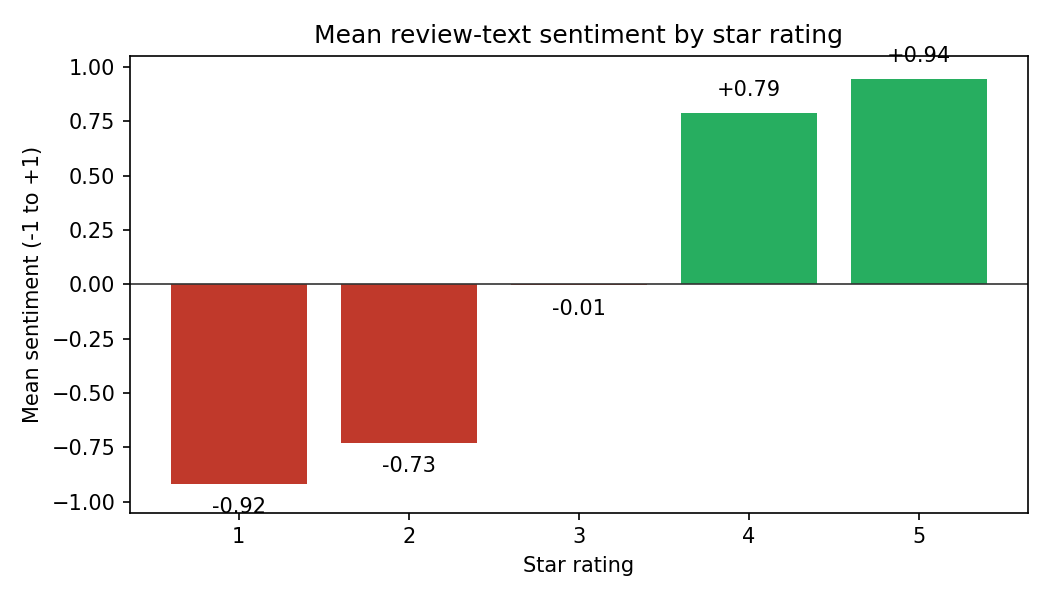

In [ ]:
from scipy.stats import spearmanr, pearsonr

pear = pearsonr(sample["stars"], sample["sentiment"])[0]
spear = spearmanr(sample["stars"], sample["sentiment"])[0]
print(f"Pearson r = {pear:.3f} | Spearman rho = {spear:.3f}")

by_star = sample.groupby("stars")["sentiment"].mean()
print(by_star)

fig, ax = plt.subplots(figsize=(7,4))
colors = ["#c0392b" if v < 0 else "#27ae60" for v in by_star.values]
bars = ax.bar(by_star.index.astype(str), by_star.values, color=colors)
ax.axhline(0, color="#333", linewidth=0.8)
ax.set_ylim(-1.05, 1.05)
ax.set_title("Mean review-text sentiment by star rating")
ax.set_xlabel("Star rating"); ax.set_ylabel("Mean sentiment (-1 to +1)")
for b, v in zip(bars, by_star.values):
    ax.text(b.get_x()+b.get_width()/2, v + (0.06 if v>=0 else -0.06),
            f"{v:+.2f}", ha="center", va="bottom" if v>=0 else "top", fontsize=10)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "sentiment_by_star_bar.png"), dpi=150)
plt.show()

### Sentiment tracks the rating closely

Pearson r = 0.78 and Spearman rho = 0.75, indicating that review text and the star rating move together closely. Mean sentiment increases monotonically across the scale and is nearly symmetric around zero:

| Stars | Mean sentiment |
|-------|----------------|
| 1 | -0.92 |
| 2 | -0.73 |
| 3 | -0.01 |
| 4 | +0.79 |
| 5 | +0.94 |

The 3-star mean sits almost exactly at zero, showing the sentiment scores are calibrated to the rating scale rather than arbitrary. Star ratings are therefore a reliable summary of review sentiment on average, which is what makes the small fraction of divergent reviews worth examining.

## Step 4b: Where text and stars disagree

The cases of interest are 5-star reviews with negative text and 1 to 2 star reviews with positive text.

In [9]:
high_star_neg = sample[(sample["stars"] >= 5) & (sample["sentiment"] < -0.5)]
low_star_pos  = sample[(sample["stars"] <= 2) & (sample["sentiment"] >  0.5)]
print(f"5-star but negative text: {len(high_star_neg):,}")
print(f"1-2 star but positive text: {len(low_star_pos):,}")

for t in high_star_neg["text"].head(3):
    print("\n[5-star / negative]", t[:300])


5-star but negative text: 1,053
1-2 star but positive text: 1,430

[5-star / negative] I wish they sucked at something so I didn't feel so bad about myself.

[5-star / negative] Omg! Best Cajun Mac and cheese ever! Truck was parked outside of Tipitinas after a show. He gave us a huge sample of their mac and I was blown away. A must!!

[5-star / negative] After looking at other reviews on Yelp, I had to come here! I also noticed seating seemed limited, but we decided to go at an off hour (even then it was still busy, but we managed to snag a table). 

I will say every review that cites this place as being slow in service is spot on - it is slow. I do


### Interpreting the disagreements

About 2.8% of reviews strongly disagree with their star rating: 1,053 five-star reviews read negative and 1,430 one or two star reviews read positive. These fall into two groups:

1. Genuine mixed reviews, for example a 5-star review that states the service is slow. The rating hides a real complaint.
2. Model limitations. The binary SST-2 model misreads sarcasm and very short exclamatory text, which are not true disagreements.

The distinction matters when reporting the result: the genuine mixed reviews support the point that a single star rating can hide a specific preference, while the model's difficulty with sarcasm is a known limitation of binary sentiment classification.

## Step 5: TF-IDF keywords, positive vs. negative

TF-IDF measures how distinctive a word is to a group relative to the whole corpus. Because only 44% of ratings are 5-star and low-star reviews are comparatively rare, the positive and negative groups are rebalanced to equal size before comparison so the negative signal is not drowned out.

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

pos = sample[sample["stars"] >= 4]
neg = sample[sample["stars"] <= 2]
k = min(len(pos), len(neg))
pos = pos.sample(k, random_state=SEED)
neg = neg.sample(k, random_state=SEED)
print(f"comparing {k:,} positive vs {k:,} negative reviews")

docs   = pd.concat([pos["text_clean"], neg["text_clean"]])
labels = np.array([1]*k + [0]*k)

vec = TfidfVectorizer(min_df=20, max_df=0.5, ngram_range=(1,2), stop_words="english")
X = vec.fit_transform(docs)
terms = np.array(vec.get_feature_names_out())

pos_mean = np.asarray(X[labels==1].mean(axis=0)).ravel()
neg_mean = np.asarray(X[labels==0].mean(axis=0)).ravel()
diff = pos_mean - neg_mean

top_pos = terms[np.argsort(diff)[-15:]][::-1]
top_neg = terms[np.argsort(diff)[:15]]
print("Top POSITIVE-leaning terms:\n", list(top_pos))
print("\nTop NEGATIVE-leaning terms:\n", list(top_neg))


comparing 18,226 positive vs 18,226 negative reviews
Top POSITIVE-leaning terms:
 ['great', 'delicious', 'amazing', 'best', 'love', 'friendly', 'definitely', 'excellent', 'good', 'awesome', 'fresh', 'favorite', 'perfect', 'atmosphere', 'loved']

Top NEGATIVE-leaning terms:
 ['minutes', 'order', 'asked', 'told', 'said', 'worst', 'didn', 'bad', 'rude', 'ordered', 'terrible', 'just', 'manager', 'horrible', 'waited']


### Positive and negative reviews describe different things

The two groups differ in subject matter, not only in tone:

- Positive terms are quality adjectives about the food and setting: delicious, amazing, fresh, best, perfect, favorite, atmosphere, friendly.
- Negative terms describe a service or wait experience: minutes, order, waited, asked, told, said, manager, rude, along with worst, terrible, and horrible.

When reviewers rate a place highly they tend to describe what they ate; when they rate it poorly they tend to describe a problem with service or waiting. Time and service words are largely absent from the positive group. This is consistent with the earlier attribute analysis, in which ambience attributes were associated with higher ratings. The aspect terms identified here (food quality, service, wait time) are also candidate inputs for a tag-embedding recommender.

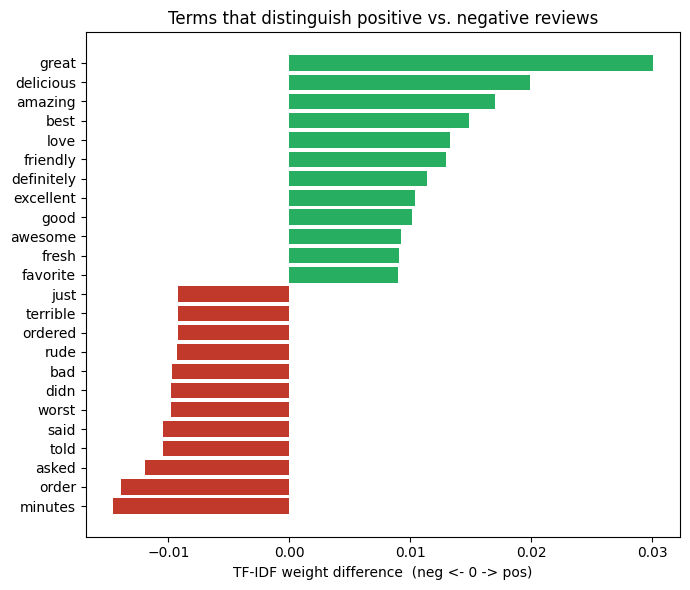

In [11]:
order = np.argsort(diff)
sel = np.concatenate([order[:12], order[-12:]])
fig, ax = plt.subplots(figsize=(7,6))
colors = ["#c0392b" if diff[i] < 0 else "#27ae60" for i in sel]
ax.barh(terms[sel], diff[sel], color=colors)
ax.set_title("Terms that distinguish positive vs. negative reviews")
ax.set_xlabel("TF-IDF weight difference  (neg <- 0 -> pos)")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "tfidf_pos_neg_terms.png"), dpi=150)
plt.show()


## Summary of findings

From about 88,000 reviews balanced across all 11 metro states:

1. Review text strongly agrees with star ratings (r = 0.78; sentiment increases monotonically from 1 to 5 stars, with 3 stars near neutral).
2. About 2.8% of reviews genuinely diverge, where a high rating carries a specific complaint such as slow service. Part of the apparent divergence is the sentiment model missing sarcasm.
3. Positive and negative reviews emphasize different topics: positive reviews focus on food quality (delicious, fresh, atmosphere) while negative reviews focus on service and wait time (minutes, waited, manager, rude).
